In [ ]:
import requests
import pandas as pd

APP_ID = "90942f9a"
APP_KEY = "40fd1c3911e8fda53169ab9a6432742d"

COUNTRY = "in"
PAGES = 2
RESULTS_PER_PAGE = 50

ROLES = [
    "AI Engineer",
    "Data Scientist",
    "Cloud Engineer",
    "Cybersecurity Analyst",
    "DevOps Engineer"
]

SKILLS_LIST = [
    "Python", "SQL", "Java", "AWS", "Azure", "GCP",
    "Docker", "Kubernetes", "TensorFlow", "PyTorch",
    "Power BI", "Tableau", "Linux", "Spark",
    "Machine Learning", "Deep Learning", "NLP",
    "Cybersecurity", "Networking"
]

OUTPUT_FILE = "adzuna_realtime_jobs_with_skills.csv"

def extract_skills(description):
    if not isinstance(description, str):
        return []
    desc = description.lower()
    return [skill for skill in SKILLS_LIST if skill.lower() in desc]


all_jobs = []

for role in ROLES:
    for page in range(1, PAGES + 1):
        url = f"https://api.adzuna.com/v1/api/jobs/{COUNTRY}/search/{page}"

        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "what": role,
            "results_per_page": RESULTS_PER_PAGE
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"Failed for role: {role}, page: {page}")
            continue

        data = response.json()

        for job in data.get("results", []):
            description = job.get("description", "")

            skills_found = extract_skills(description)

            all_jobs.append({
                "Search_Role": role,
                "Job_Title": job.get("title"),
                "Company": job.get("company", {}).get("display_name"),
                "Location": job.get("location", {}).get("display_name"),
                "Category": job.get("category", {}).get("label"),
                "Salary_Min": job.get("salary_min"),
                "Salary_Max": job.get("salary_max"),
                "Posting_Date": job.get("created"),
                "Extracted_Skills": ", ".join(skills_found),
                "Skill_Count": len(skills_found)
            })

df = pd.DataFrame(all_jobs)

df.drop_duplicates(inplace=True)

df["Posting_Date"] = pd.to_datetime(df["Posting_Date"]).dt.date
df["Salary_Min"].fillna(0, inplace=True)
df["Salary_Max"].fillna(0, inplace=True)


df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Data saved successfully: {OUTPUT_FILE}")
print(f"📊 Total records collected: {len(df)}")


✅ Data saved successfully: adzuna_realtime_jobs_with_skills.csv
📊 Total records collected: 479


/tmp/ipykernel_2921/2189882093.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salary_Min"].fillna(0, inplace=True)
/tmp/ipykernel_2921/2189882093.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
import pandas as pd
df = pd.read_csv("raw_jobs.csv")
df.head()

,job_title,company,location,category,salary_min,salary_max,contract_type,skills,created_date
0,Software Engineer,Marisree Technologies,"Hyderabad, Telangana",IT Jobs,NaN,NaN,NaN,c,2026-02-17T09:43:05Z
1,Software Engineer,Brillio,"Mumbai, Maharashtra",IT Jobs,NaN,NaN,NaN,"python, c, angular",2026-03-01T16:48:19Z
2,Software Engineer,Sedgwick India,"Bangalore, Karnataka",IT Jobs,NaN,NaN,NaN,c,2026-02-09T08:23:47Z
3,Software Engineer,Glood.AI - Personalization & Experience For Sh...,India,IT Jobs,NaN,NaN,NaN,c,2026-02-20T16:40:56Z
4,Software Engineer,ShimentoX Technologies,"Hyderabad, Telangana",IT Jobs,NaN,NaN,NaN,"python, java, c",2026-02-26T18:29:46Z


In [ ]:
df.isnull().sum()

,0
job_title,0
company,166
location,0
category,0
salary_min,10908
salary_max,10909
contract_type,13444
skills,3
created_date,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("raw_jobs.csv")

print("Shape:", df.shape)
df.head()

Shape: (14762, 9)


,job_title,company,location,category,salary_min,salary_max,contract_type,skills,created_date
0,Software Engineer,Marisree Technologies,"Hyderabad, Telangana",IT Jobs,NaN,NaN,NaN,c,2026-02-17T09:43:05Z
1,Software Engineer,Brillio,"Mumbai, Maharashtra",IT Jobs,NaN,NaN,NaN,"python, c, angular",2026-03-01T16:48:19Z
2,Software Engineer,Sedgwick India,"Bangalore, Karnataka",IT Jobs,NaN,NaN,NaN,c,2026-02-09T08:23:47Z
3,Software Engineer,Glood.AI - Personalization & Experience For Sh...,India,IT Jobs,NaN,NaN,NaN,c,2026-02-20T16:40:56Z
4,Software Engineer,ShimentoX Technologies,"Hyderabad, Telangana",IT Jobs,NaN,NaN,NaN,"python, java, c",2026-02-26T18:29:46Z


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14762 entries, 0 to 14761
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   job_title      14762 non-null  object 
 1   company        14596 non-null  object 
 2   location       14762 non-null  object 
 3   category       14762 non-null  object 
 4   salary_min     3854 non-null   float64
 5   salary_max     3853 non-null   float64
 6   contract_type  1318 non-null   object 
 7   skills         14759 non-null  object 
 8   created_date   14762 non-null  object 
dtypes: float64(2), object(7)
memory usage: 1.0+ MB


,0
job_title,0
company,166
location,0
category,0
salary_min,10908
salary_max,10909
contract_type,13444
skills,3
created_date,0


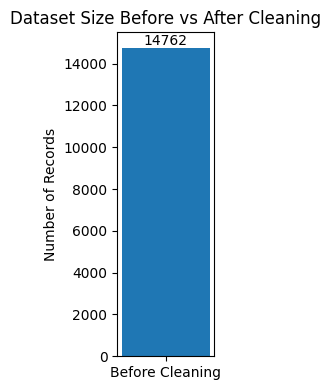

In [ ]:
plt.figure(figsize=(2,4))

labels = ["Before Cleaning"]
values = [len(df)]

bars = plt.bar(labels, values)

# Add labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.title("Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [ ]:
# 🔥 Drop useless columns
df = df.drop(columns=["salary_min", "salary_max", "contract_type"], errors='ignore')

# Remove duplicates
df = df.drop_duplicates()

# Remove rows with missing important fields
df = df[df["skills"].notna()]

# Lowercase text
df["job_title"] = df["job_title"].str.lower()
df["skills"] = df["skills"].str.lower()

print("After cleaning:", df.shape)

After cleaning: (14759, 6)


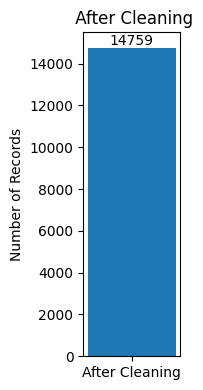

In [ ]:
plt.figure(figsize=(2,4))

labels = ["After Cleaning"]
values = [len(df)]

bars = plt.bar(labels, values)

# Add labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.title(" After Cleaning")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [ ]:
# Convert date
df["created_date"] = pd.to_datetime(df["created_date"], errors='coerce')

df["year"] = df["created_date"].dt.year
df["month"] = df["created_date"].dt.month
df["dayofweek"] = df["created_date"].dt.dayofweek

# Skills count
df["skills_count"] = df["skills"].apply(lambda x: len(str(x).split(",")))

# City extraction
df["city"] = df["location"].apply(lambda x: str(x).split(",")[0])

In [ ]:
df[["skills", "skills_count", "year", "month", "dayofweek", "city"]].head()

,skills,skills_count,year,month,dayofweek,city
0,c,1,2026,2,1,Hyderabad
1,"python, c, angular",3,2026,3,6,Mumbai
2,c,1,2026,2,0,Bangalore
3,c,1,2026,2,4,India
4,"python, java, c",3,2026,2,3,Hyderabad


In [ ]:
def classify_role(row):
    text = str(row["job_title"]) + " " + str(row["skills"])
    text = text.lower()

    if any(x in text for x in ["sql","power bi","tableau","data","analytics","excel"]):
        return "Data"

    elif any(x in text for x in ["machine learning","ai","nlp","deep learning","tensorflow","pytorch"]):
        return "AI"

    elif any(x in text for x in ["aws","azure","gcp","cloud"]):
        return "Cloud"

    elif any(x in text for x in ["docker","kubernetes","devops","ci/cd"]):
        return "DevOps"

    elif any(x in text for x in ["security","cyber","network","firewall"]):
        return "Cybersecurity"

    else:
        return "Other"

df["job_role"] = df.apply(classify_role, axis=1)

# 🔥 Remove noise
df = df[df["job_role"] != "Other"]

print(df["job_role"].value_counts())

job_role
Data             4350
AI               1052
Cloud             442
DevOps             86
Cybersecurity      66
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode city
df["city_encoded"] = LabelEncoder().fit_transform(df["city"])

# Skills encoding
skills_encoded = df["skills"].str.get_dummies(sep=", ")
df = pd.concat([df, skills_encoded], axis=1)

In [ ]:
df["city_encoded"].head()

,city_encoded
7,64
10,64
14,64
28,17
33,64


In [ ]:
important_features = [
    "skills_count",
    "year",
    "month",
    "dayofweek",
    "city_encoded"
]

skill_cols = skills_encoded.columns.tolist()

X = df[important_features + skill_cols].fillna(0)
y = df["job_role"]

print("Total features:", len(X.columns))

Total features: 43


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardisation applied successfully")

Standardisation applied successfully


In [ ]:
top_skills = df[skill_cols].sum().sort_values(ascending=False).head(10)
print("Top Skills in Market:\n", top_skills)

Top Skills in Market:
 c                   5996
sql                 1196
machine learning    1004
excel                798
java                 730
python               729
git                  676
aws                  537
javascript           420
mysql                372
dtype: int64


In [ ]:
import pandas as pd

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head()

,skills_count,year,month,dayofweek,city_encoded,angular,aws,azure,c,c++,...,pytorch,react,scikit-learn,spring,spring boot,sql,tableau,tensorflow,terraform,vue
0,0.152449,0.572787,-0.632583,0.893003,0.171168,-0.229496,3.188375,-0.256818,0.0,-0.089833,...,-0.117751,-0.2303,-0.087927,-0.152914,-0.119199,2.003342,-0.086958,-0.122045,-0.067256,-0.090771
1,-0.344607,0.572787,-0.632583,1.451980,0.171168,-0.229496,-0.313639,-0.256818,0.0,-0.089833,...,-0.117751,-0.2303,-0.087927,-0.152914,-0.119199,-0.499166,-0.086958,-0.122045,-0.067256,-0.090771
2,1.643617,0.572787,-0.632583,-0.783929,0.171168,-0.229496,-0.313639,-0.256818,0.0,-0.089833,...,-0.117751,-0.2303,-0.087927,6.539604,8.389336,2.003342,-0.086958,-0.122045,-0.067256,-0.090771
3,0.152449,0.572787,-0.632583,0.334025,-1.178839,-0.229496,-0.313639,3.893806,0.0,-0.089833,...,-0.117751,-0.2303,-0.087927,-0.152914,-0.119199,-0.499166,-0.086958,-0.122045,-0.067256,-0.090771
4,-0.344607,0.572787,-0.632583,-0.783929,0.171168,-0.229496,-0.313639,-0.256818,0.0,-0.089833,...,-0.117751,-0.2303,-0.087927,-0.152914,-0.119199,-0.499166,-0.086958,-0.122045,-0.067256,-0.090771


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("Clusters added")

Clusters added


In [ ]:
print(df.groupby("cluster")["job_role"].value_counts())

cluster  job_role     
0        Data              401
         Cloud              32
         AI                 16
         DevOps              3
1        Data             3719
         AI               1001
         Cloud             357
         Cybersecurity      64
         DevOps             39
2        Data               52
         DevOps             42
         Cloud              27
         AI                 11
3        Data               83
         AI                 23
4        Data               95
         Cloud              26
         Cybersecurity       2
         DevOps              2
         AI                  1
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# BEFORE
before_records = df.notnull().sum()

# CLEANING
df_clean = df.copy()
df_clean = df_clean.drop(columns=["salary_min", "salary_max", "contract_type"], errors='ignore')
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean["skills"].notna()]

In [ ]:
print(df_clean)

                                             job_title  \
7                                    software engineer   
10                                   software engineer   
14                                   software engineer   
28                                sr software engineer   
33                            senior software engineer   
...                                                ...   
14755                                gcp data engineer   
14756                           3563119-senior manager   
14757                         sr. data engineer| thane   
14760                                ht- data engineer   
14761  quant analytics senior associate - cash & check   

                                 company              location category  \
7                          ValueMomentum  Hyderabad, Telangana  IT Jobs   
10                               HCLTech  Hyderabad, Telangana  IT Jobs   
14              Lorven Technologies Inc.  Hyderabad, Telangana  IT Jobs   
28 

In [ ]:
df_clean["job_title_freq"] = df_clean["job_title"].map(df_clean["job_title"].value_counts())
print(df_clean.head())

                   job_title                   company              location  \
7          software engineer             ValueMomentum  Hyderabad, Telangana   
10         software engineer                   HCLTech  Hyderabad, Telangana   
14         software engineer  Lorven Technologies Inc.  Hyderabad, Telangana   
28      sr software engineer                       HME  Bangalore, Karnataka   
33  senior software engineer                Demandbase  Hyderabad, Telangana   

   category                                         skills  \
7   IT Jobs                                    c, sql, aws   
10  IT Jobs                                       c, excel   
14  IT Jobs  java, c, sql, postgresql, spring, spring boot   
28  IT Jobs                           c, azure, kubernetes   
33  IT Jobs                                       c, excel   

                created_date  year  month  dayofweek  skills_count  ...  \
7  2026-02-28 18:43:02+00:00  2026      2          5             3  ...

R2 Score: 0.007405126925976835


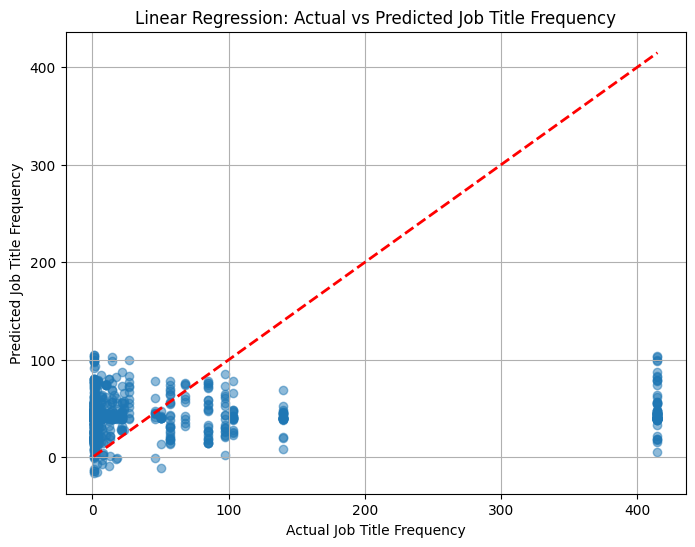

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Ensure 'high_skill' column exists
# This line creates the 'high_skill' column if it's not already in df_clean.
if "high_skill" not in df_clean.columns:
    df_clean["high_skill"] = df_clean["skills_count"] > df_clean["skills_count"].median()

X = df_clean[[
    "skills_count","year","month","dayofweek","high_skill",
    "c","sql","aws","azure","kubernetes"
]]

y = df_clean["job_title_freq"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("R2 Score:", model.score(X_test, y_test))

# Visualize actual vs predicted values for this model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, model.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Job Title Frequency")
plt.ylabel("Predicted Job Title Frequency")
plt.title("Linear Regression: Actual vs Predicted Job Title Frequency")
plt.grid(True)
plt.show()

    Skills_Count  Actual_Year  Predicted_Year
7              3         2026     2024.894451
10             2         2026     2025.164580
14             6         2026     2024.084065
28             3         2026     2024.894451
33             2         2026     2025.164580
36             2         2026     2025.164580
42             2         2026     2025.164580
45             3         2026     2024.894451
51             3         2026     2024.894451
54             8         2026     2023.543808

Model Equation:
Year = -0.27 * Skills_Count + 2025.70


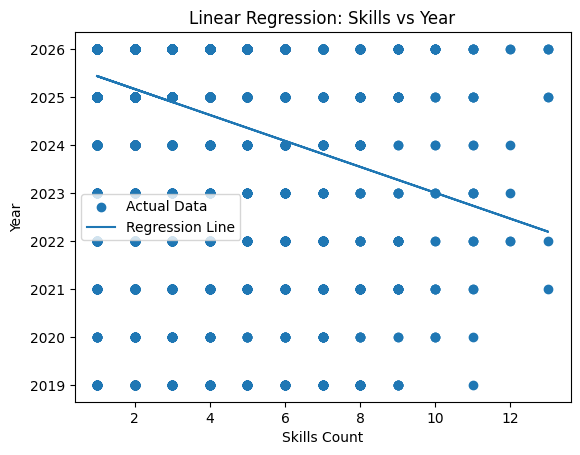

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 🔷 Step 1: Select Features
X_reg = df_clean[['skills_count']]
y_reg = df_clean['year']

# 🔷 Step 2: Train Model
model_reg = LinearRegression()
model_reg.fit(X_reg, y_reg)

# 🔷 Step 3: Predictions
y_pred = model_reg.predict(X_reg)

# 🔷 Step 4: Show Output (Actual vs Predicted)
result = pd.DataFrame({
    "Skills_Count": X_reg['skills_count'],
    "Actual_Year": y_reg,
    "Predicted_Year": y_pred
})

print(result.head(10))  # show first 10 rows

# 🔷 Step 5: Model Equation
print("\nModel Equation:")
print(f"Year = {model_reg.coef_[0]:.2f} * Skills_Count + {model_reg.intercept_:.2f}")

# 🔷 Step 6: Visualization (Regression Line)
plt.figure()
plt.scatter(X_reg, y_reg, label="Actual Data")
plt.plot(X_reg, y_pred, label="Regression Line")
plt.xlabel("Skills Count")
plt.ylabel("Year")
plt.title("Linear Regression: Skills vs Year")
plt.legend()
plt.show()

In [ ]:
top_skills = df_clean[skill_cols].sum().sort_values(ascending=False).head(30).index.tolist()

# 🔹 Remove rare classes
role_counts = df_clean["job_role"].value_counts()
valid_roles = role_counts[role_counts > 50].index
df_clean = df_clean[df_clean["job_role"].isin(valid_roles)]

# 🔹 Features
X = df_clean[important_features + top_skills].fillna(0)
y = df_clean["job_role"]

# 🔹 Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 🔹 Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# 🔹 Prediction
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6555462885738115
               precision    recall  f1-score   support

           AI       0.41      0.47      0.44       210
        Cloud       0.62      0.85      0.72        89
Cybersecurity       0.02      0.23      0.04        13
         Data       0.88      0.69      0.77       870
       DevOps       0.20      0.35      0.26        17

     accuracy                           0.66      1199
    macro avg       0.43      0.52      0.45      1199
 weighted avg       0.76      0.66      0.70      1199



In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,AI,Data
1,Data,Data
2,Data,Data
3,Cloud,Cloud
4,Data,Data
5,Data,Cybersecurity
6,Data,Data
7,Data,AI
8,Data,Data
9,AI,DevOps


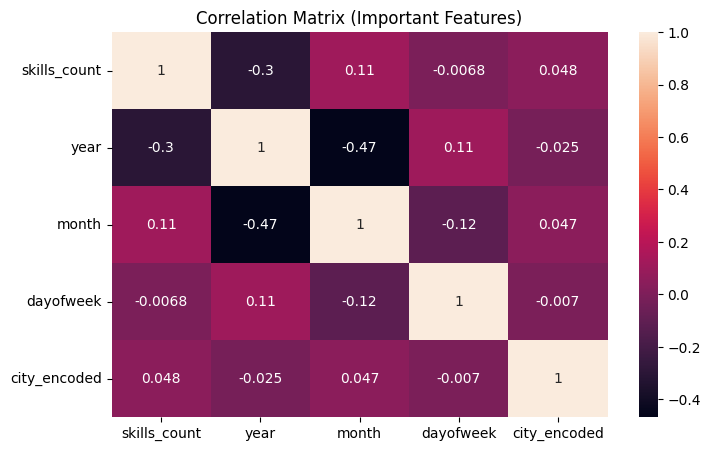

In [ ]:
import seaborn as sns
important_cols = ["skills_count", "year", "month", "dayofweek", "city_encoded"]

corr = df_clean[important_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix (Important Features)")
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# ==============================
# 🔷 STEP 8: Z-TEST
# ==============================
mean_val = df_clean["skills_count"].mean()
z_stat = (mean_val - 5) / (df_clean["skills_count"].std() / np.sqrt(len(df_clean)))
p_val = stats.norm.sf(abs(z_stat)) * 2

print("\n🔹 Z-Test:")
print("Z-Statistic:", z_stat)
print("P-Value:", p_val)

# ==============================
# 🔷 STEP 9: T-TEST
# ==============================
data_skills = df_clean[df_clean["job_role"] == "Data"]["skills_count"]
ai_skills = df_clean[df_clean["job_role"] == "AI"]["skills_count"]

t_stat, p_val = stats.ttest_ind(data_skills, ai_skills, equal_var=False)

print("\n🔹 T-Test (Data vs AI):")
print("T-Statistic:", t_stat)
print("P-Value:", p_val)

# ==============================
# 🔷 STEP 10: ANOVA TEST
# ==============================
groups = [group["skills_count"].values for name, group in df_clean.groupby("job_role")]
f_stat, p_val = stats.f_oneway(*groups)

print("\n🔹 ANOVA Test:")
print("F-Statistic:", f_stat)
print("P-Value:", p_val)

# ==============================
# 🔷 STEP 11: CHI-SQUARE TEST
# ==============================
df_clean["high_skill"] = df_clean["skills_count"] > df_clean["skills_count"].median()

cont_table = pd.crosstab(df_clean["job_role"], df_clean["high_skill"])

chi2, p, dof, exp = stats.chi2_contingency(cont_table)

print("\n🔹 Chi-Square Test:")
print("Chi2:", chi2)
print("P-Value:", p)


🔹 Z-Test:
Z-Statistic: -88.76253917272354
P-Value: 0.0

🔹 T-Test (Data vs AI):
T-Statistic: 14.225451089797552
P-Value: 3.788272731273847e-44

🔹 ANOVA Test:
F-Statistic: 45.796379363789015
P-Value: 5.909241020041109e-38

🔹 Chi-Square Test:
Chi2: 193.8522927087691
P-Value: 7.877858037818255e-41


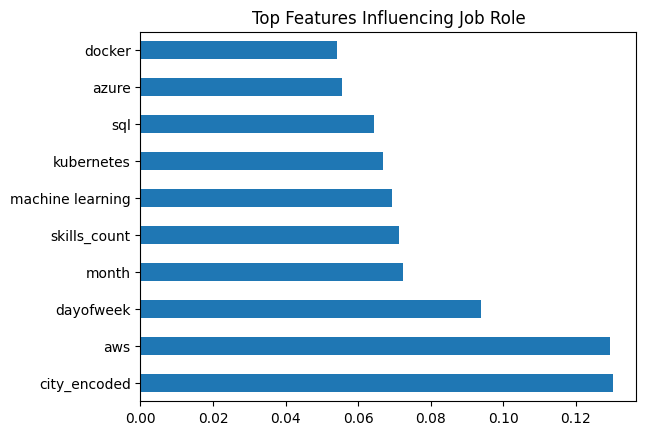

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Influencing Job Role")
plt.show()

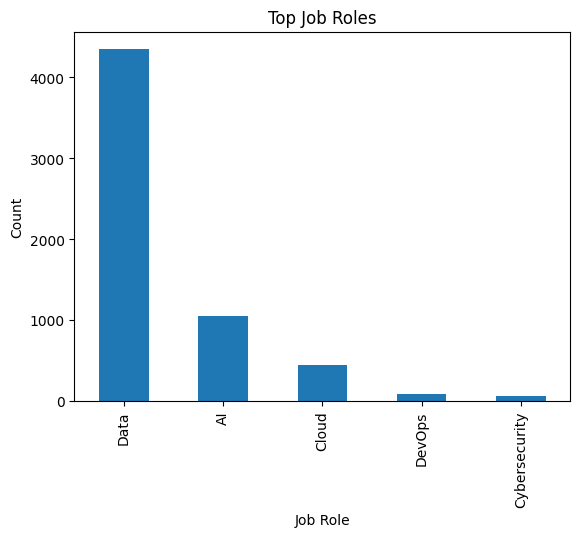

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df_clean["job_role"].value_counts().plot(kind='bar')
plt.title("Top Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

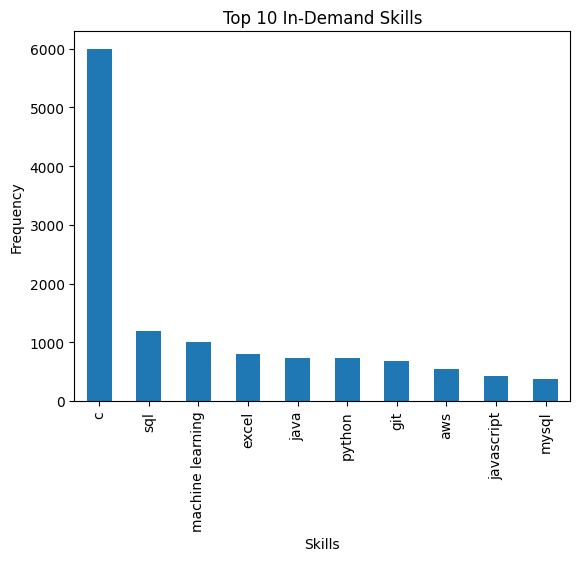

In [ ]:
plt.figure()

df["skills"].str.get_dummies(sep=", ").sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind='bar')

plt.title("Top 10 In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.show()

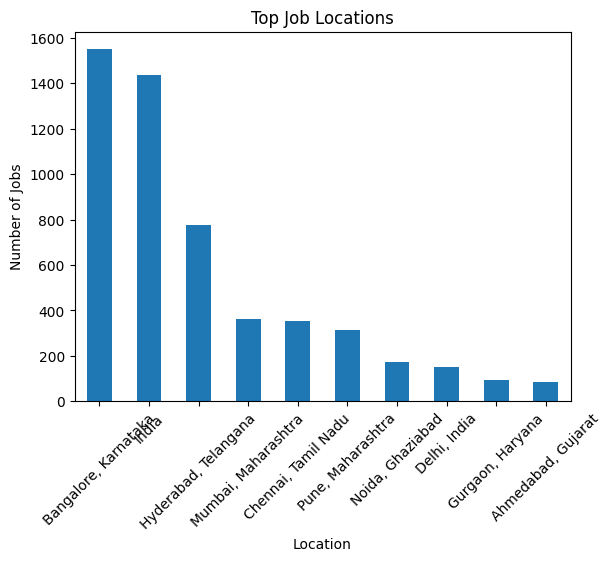

In [ ]:
plt.figure()

df["location"].value_counts().head(10).plot(kind='bar')

plt.title("Top Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

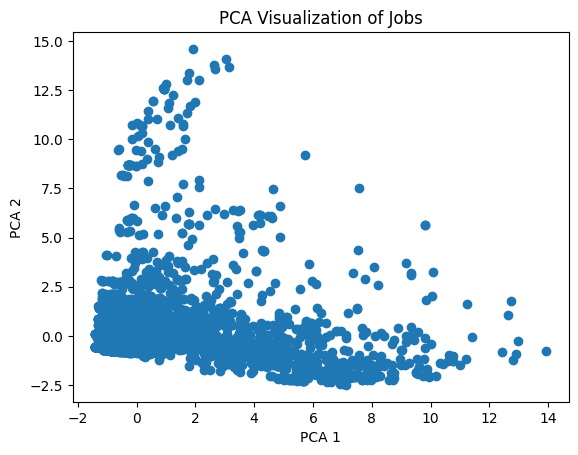

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization of Jobs")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

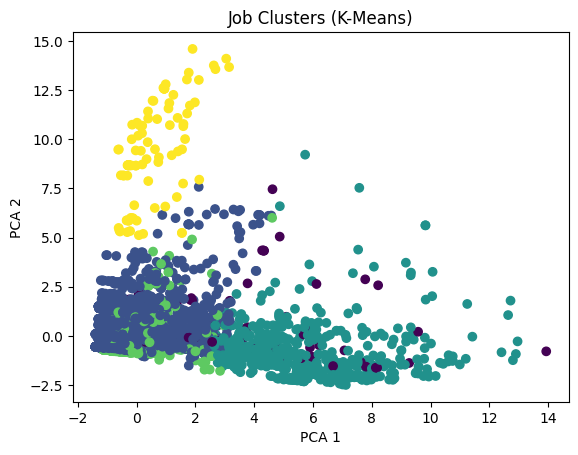

In [ ]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign clusters to the df_clean DataFrame
df_clean["cluster"] = clusters

# Plot clusters using df_clean
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_clean["cluster"])
plt.title("Job Clusters (K-Means)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

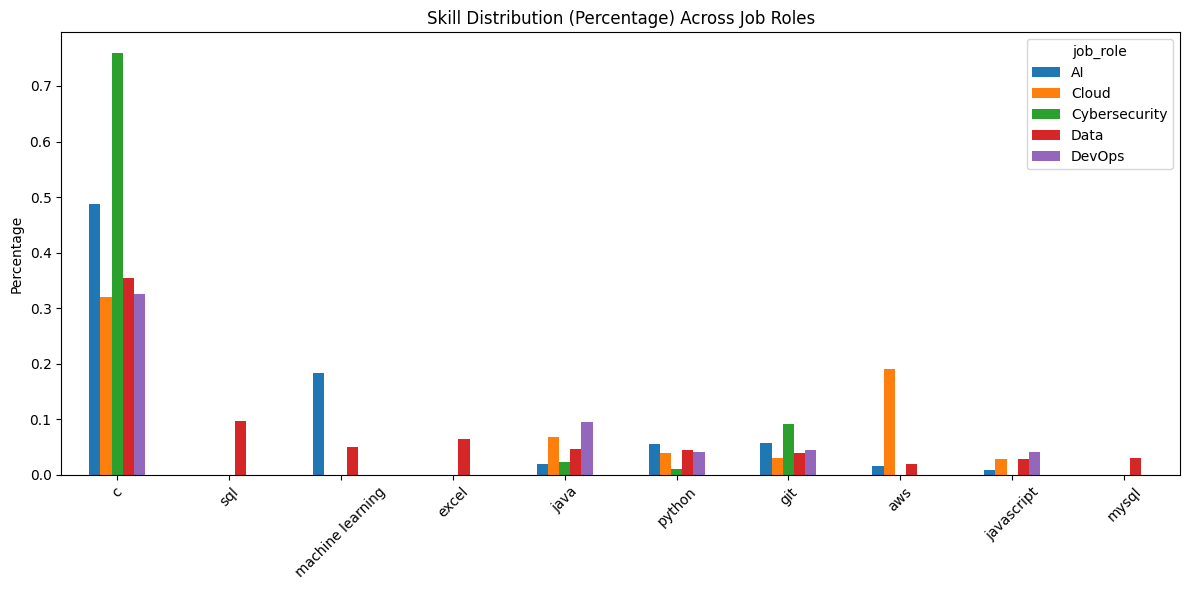

In [ ]:
df_skills = df["skills"].str.get_dummies(sep=", ")

# Convert to percentage
role_skill_percent = df.groupby("job_role")[df_skills.columns].sum()

role_skill_percent = role_skill_percent.div(role_skill_percent.sum(axis=1), axis=0)

# Select top 10 skills overall
top_skills = df_skills.sum().sort_values(ascending=False).head(10).index

# Plot
role_skill_percent[top_skills].T.plot(kind='bar', figsize=(12,6))

plt.title("Skill Distribution (Percentage) Across Job Roles")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def classify_role(row):
    text = str(row["job_title"]) + " " + str(row["skills"])
    text = text.lower()

    if any(x in text for x in ["sql","power bi","tableau","data","analytics","excel"]):
        return "Data"
    elif any(x in text for x in ["machine learning","ai","nlp","tensorflow","pytorch"]):
        return "AI"
    elif any(x in text for x in ["aws","azure","gcp","cloud"]):
        return "Cloud"
    elif any(x in text for x in ["docker","kubernetes","devops"]):
        return "DevOps"
    elif any(x in text for x in ["security","cyber","network"]):
        return "Cybersecurity"
    else:
        return "Other"

df_clean["job_role"] = df_clean.apply(classify_role, axis=1)

In [ ]:
# ==============================
# 🔷 INSTALL & SETUP
# ==============================
!pip install ipywidgets -q

from google.colab import output
output.enable_custom_widget_manager()

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==============================
# 🔷 CONFIG
# ==============================
ALL_SKILLS = [
    "python", "sql", "java", "aws", "azure", "gcp", "docker", "kubernetes",
    "tensorflow", "pytorch", "power bi", "tableau", "linux", "spark",
    "machine learning", "deep learning", "nlp", "cybersecurity", "networking",
    "excel", "ci/cd", "devops", "cloud", "data", "analytics", "firewall", "network"
]

ROLES = ["AI", "Cloud", "Cybersecurity", "Data", "DevOps"]

ROLE_COLORS = {
    "AI":            "#185FA5",
    "Cloud":         "#0F6E56",
    "Cybersecurity": "#993C1D",
    "Data":          "#533AAB",
    "DevOps":        "#854F0B"
}

ROLE_KEYWORDS = {
    "AI":            ["machine learning", "ai", "nlp", "deep learning", "tensorflow", "pytorch"],
    "Cloud":         ["aws", "azure", "gcp", "cloud"],
    "Cybersecurity": ["cybersecurity", "cyber", "networking", "firewall", "network"],
    "Data":          ["sql", "power bi", "tableau", "data", "analytics", "excel"],
    "DevOps":        ["docker", "kubernetes", "devops", "ci/cd"]
}

ROLE_SKILLS = {
    "AI":            ["machine learning", "deep learning", "nlp", "tensorflow", "pytorch", "python", "spark"],
    "Cloud":         ["aws", "azure", "gcp", "cloud", "linux", "docker", "kubernetes"],
    "Cybersecurity": ["cybersecurity", "networking", "firewall", "network", "linux", "python"],
    "Data":          ["sql", "power bi", "tableau", "excel", "data", "analytics", "python", "spark"],
    "DevOps":        ["docker", "kubernetes", "ci/cd", "devops", "linux", "aws", "azure"]
}

# ==============================
# 🔷 PREDICTION LOGIC
# ==============================
def score_roles(selected_skills):
    scores = {}
    for role in ROLES:
        score = 0
        kws     = ROLE_KEYWORDS[role]
        related = ROLE_SKILLS[role]
        for s in selected_skills:
            if s in kws:
                score += 2
            elif s in related:
                score += 0.5
        scores[role] = max(score, 0)

    total = sum(scores.values()) or 1
    return {r: scores[r] / total for r in ROLES}

# ==============================
# 🔷 PLOTTING FUNCTION
# ==============================
def plot_dashboard(selected_skills, probs):
    sorted_roles = sorted(ROLES, key=lambda r: probs[r], reverse=True)
    best         = sorted_roles[0]
    best_pct     = round(probs[best] * 100)
    top_skills   = ROLE_SKILLS[best]

    fig = plt.figure(figsize=(14, 7))
    fig.patch.set_facecolor("#F8F8F8")
    fig.suptitle(
        f"Job Role Predictor Dashboard",
        fontsize=16, fontweight="bold", y=0.98, color="#1a1a1a"
    )

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

    # ── Panel 1: Predicted Role ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor(ROLE_COLORS[best])
    ax1.axis("off")
    ax1.text(0.5, 0.72, "Predicted Role", ha="center", va="center",
             fontsize=10, color="white", alpha=0.8, transform=ax1.transAxes)
    ax1.text(0.5, 0.45, best, ha="center", va="center",
             fontsize=22, fontweight="bold", color="white", transform=ax1.transAxes)
    ax1.text(0.5, 0.18, f"{best_pct}% confidence", ha="center", va="center",
             fontsize=11, color="white", alpha=0.9, transform=ax1.transAxes)
    ax1.set_title("", pad=4)

    # ── Panel 2: Metric Cards ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis("off")
    ax2.set_facecolor("#FFFFFF")

    metrics = [
        ("Skills Selected",  str(len(selected_skills))),
        ("Pool Coverage",    f"{round(len(selected_skills)/len(ALL_SKILLS)*100)}%"),
        ("Top Confidence",   f"{best_pct}%"),
        ("Roles Evaluated",  str(len(ROLES)))
    ]

    for i, (label, value) in enumerate(metrics):
        col = i % 2
        row = i // 2
        x   = 0.05 + col * 0.5
        y   = 0.85 - row * 0.45

        ax2.add_patch(plt.Rectangle(
            (x, y - 0.32), 0.42, 0.32,
            transform=ax2.transAxes, clip_on=False,
            facecolor="#EFEFEF", edgecolor="#DDDDDD", linewidth=0.8,
            zorder=2
        ))
        ax2.text(x + 0.21, y - 0.08, value,
                 ha="center", va="center", fontsize=18, fontweight="bold",
                 color="#1a1a1a", transform=ax2.transAxes, zorder=3)
        ax2.text(x + 0.21, y - 0.24, label,
                 ha="center", va="center", fontsize=8.5, color="#666666",
                 transform=ax2.transAxes, zorder=3)

    ax2.set_title("Summary", fontsize=11, pad=6, color="#444444")

    # ── Panel 3: Selected Skills ──────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis("off")
    ax3.set_facecolor("#FFFFFF")
    ax3.set_title("Selected Skills", fontsize=11, pad=6, color="#444444")

    if selected_skills:
        text_str = " · ".join([s.title() for s in selected_skills])
        ax3.text(0.5, 0.5, text_str,
                 ha="center", va="center", fontsize=9,
                 color="#333333", wrap=True, transform=ax3.transAxes,
                 multialignment="center",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="#EFEFEF", edgecolor="#CCCCCC"))
    else:
        ax3.text(0.5, 0.5, "No skills selected",
                 ha="center", va="center", fontsize=10,
                 color="#AAAAAA", transform=ax3.transAxes)

    # ── Panel 4: Confidence Bar Chart ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax4.set_facecolor("#FFFFFF")

    pcts   = [round(probs[r] * 100) for r in sorted_roles]
    colors = [ROLE_COLORS[r] for r in sorted_roles]
    bars   = ax4.barh(sorted_roles, pcts, color=colors, height=0.55, edgecolor="none")

    for bar, pct in zip(bars, pcts):
        ax4.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                 f"{pct}%", va="center", fontsize=10, color="#333333")

    ax4.set_xlim(0, max(pcts) + 12)
    ax4.set_xlabel("Confidence (%)", fontsize=9, color="#666666")
    ax4.tick_params(axis="y", labelsize=10, colors="#333333")
    ax4.tick_params(axis="x", labelsize=8,  colors="#888888")
    ax4.spines[["top","right","left"]].set_visible(False)
    ax4.spines["bottom"].set_color("#DDDDDD")
    ax4.set_facecolor("#FAFAFA")
    ax4.set_title("Confidence by Role", fontsize=11, pad=6, color="#444444")

    # ── Panel 5: Top Skills for Best Role ────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.set_facecolor("#FAFAFA")
    ax5.set_title(f"Top Skills · {best}", fontsize=11, pad=6, color="#444444")

    top6      = top_skills[:6]
    weights   = [len(top6) - i for i in range(len(top6))]
    bar_cols  = [ROLE_COLORS[best] if s in selected_skills else "#CCCCCC" for s in top6]

    ax5.barh(top6[::-1], weights[::-1], color=bar_cols[::-1], height=0.55, edgecolor="none")
    ax5.axis("off")

    legend_patches = [
        mpatches.Patch(color=ROLE_COLORS[best], label="You have it"),
        mpatches.Patch(color="#CCCCCC",          label="Missing")
    ]
    ax5.legend(handles=legend_patches, loc="lower right",
               fontsize=8, frameon=False)

    for i, skill in enumerate(top6[::-1]):
        ax5.text(-0.1, i, skill.title(), va="center", ha="right",
                 fontsize=9, color="#333333")

    plt.savefig("/tmp/dashboard.png", dpi=130, bbox_inches="tight",
                facecolor="#F8F8F8")
    plt.show()
    plt.close()

# ==============================
# 🔷 WIDGET UI
# ==============================
display(HTML("""
<style>
  .widget-label { font-size: 13px !important; }
  .dash-title {
    font-family: sans-serif; font-size: 18px; font-weight: 600;
    color: #1a1a1a; margin: 12px 0 4px;
  }
  .dash-sub { font-family: sans-serif; font-size: 13px; color: #666; margin-bottom: 12px; }
</style>
<div class="dash-title">Job Role Predictor</div>
<div class="dash-sub">Select your skills below, then click <strong>Predict</strong>.</div>
"""))

skills_selector = widgets.SelectMultiple(
    options   = ALL_SKILLS,
    value     = [],
    rows      = 12,
    description = "Skills:",
    layout    = widgets.Layout(width="420px"),
    style     = {"description_width": "60px"}
)

selected_label = widgets.Label(value="0 skills selected")

predict_btn = widgets.Button(
    description  = "Predict Job Role",
    button_style = "primary",
    layout       = widgets.Layout(width="200px", height="38px")
)

reset_btn = widgets.Button(
    description  = "Reset",
    button_style = "warning",
    layout       = widgets.Layout(width="100px", height="38px")
)

output_area = widgets.Output()

def on_skill_change(change):
    n = len(skills_selector.value)
    selected_label.value = f"{n} skill{'s' if n != 1 else ''} selected"

def on_predict(b):
    selected = list(skills_selector.value)
    with output_area:
        clear_output(wait=True)
        if not selected:
            print("⚠️  Please select at least one skill from the list.")
            return
        probs = score_roles(selected)
        plot_dashboard(selected, probs)

        best     = max(probs, key=probs.get)
        best_pct = round(probs[best] * 100)
        missing  = [s for s in ROLE_SKILLS[best] if s not in selected][:3]

        print(f"\n🎯  Predicted Role : {best}  ({best_pct}% confidence)")
        print(f"📌  Skill coverage : {len(selected)}/{len(ALL_SKILLS)} skills selected")
        if missing:
            print(f"💡  To strengthen '{best}', consider adding: {', '.join(missing)}")

def on_reset(b):
    skills_selector.value = []
    selected_label.value  = "0 skills selected"
    with output_area:
        clear_output()

skills_selector.observe(on_skill_change, names="value")
predict_btn.on_click(on_predict)
reset_btn.on_click(on_reset)

display(
    skills_selector,
    selected_label,
    widgets.HBox([predict_btn, reset_btn], layout=widgets.Layout(gap="10px", margin="8px 0")),
    output_area
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00


SelectMultiple(description='Skills:', layout=Layout(width='420px'), options=('python', 'sql', 'java', 'aws', '…

Label(value='0 skills selected')

Output()

In [ ]:
# ==============================
# 🔥 WIDGET: Job Role Predictor
# ==============================

!pip install ipywidgets -q
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ==============================
# STEP 1: Create high_skill column (if not already done)
# ==============================
if "high_skill" not in df_clean.columns:
    df_clean["high_skill"] = (
        df_clean["skills_count"] > df_clean["skills_count"].median()
    ).astype(int)

# ==============================
# STEP 2: Define the exact skill columns that exist in df_clean
# ==============================
SKILL_COLS = ["sql", "aws", "azure", "kubernetes"]

# Filter to only those that actually exist in df_clean
SKILL_COLS = [s for s in SKILL_COLS if s in df_clean.columns]

# ==============================
# STEP 3: Define features and train the classifier fresh
# ==============================
MODEL_FEATURES = ["skills_count", "year", "month", "dayofweek", "high_skill"] + SKILL_COLS

X_widget = df_clean[MODEL_FEATURES].fillna(0)
y_widget = df_clean["job_role"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_widget, y_widget, test_size=0.2, stratify=y_widget, random_state=42
)

widget_model = RandomForestClassifier(n_estimators=200, random_state=42)
widget_model.fit(X_tr, y_tr)

print("✅ Model trained. Accuracy:", round(widget_model.score(X_te, y_te), 3))

# ==============================
# STEP 4: Precompute top skills per role for display
# ==============================
skills_encoded_widget = df_clean["skills"].str.get_dummies(sep=", ")
SKILLS_LIST = skills_encoded_widget.columns.tolist()
# Fix: df_clean already contains the skill columns, so no need to join again.
role_skill_matrix = df_clean.groupby("job_role")[SKILLS_LIST].sum()

# ==============================
# STEP 5: Build the Widget UI
# ==============================
skills_widget = widgets.SelectMultiple(
    options=SKILLS_LIST,
    description='Skills',
    layout=widgets.Layout(width='60%', height='150px')
)

predict_button = widgets.Button(
    description="Predict Job Role",
    button_style='success'
)

output_area = widgets.Output()

display(
    widgets.Label("Select one or more skills, then click Predict:"),
    skills_widget,
    predict_button,
    output_area
)

# ==============================
# STEP 6: Prediction Function
# ==============================
def predict_job(b):
    with output_area:
        clear_output()

        selected_skills = list(skills_widget.value)

        if not selected_skills:
            print("⚠️ Please select at least one skill.")
            return

        # Build input row with exact model features
        input_data = pd.DataFrame(
            np.zeros((1, len(MODEL_FEATURES))), columns=MODEL_FEATURES
        )

        input_data["skills_count"] = len(selected_skills)
        input_data["year"]       = df_clean["year"].median()
        input_data["month"]      = df_clean["month"].median()
        input_data["dayofweek"]  = df_clean["dayofweek"].median()
        input_data["high_skill"] = int(len(selected_skills) > df_clean["skills_count"].median())

        # Set individual skill flags
        for skill in selected_skills:
            if skill in MODEL_FEATURES:
                input_data[skill] = 1

        # Predict
        prediction = widget_model.predict(input_data)[0]
        probs      = widget_model.predict_proba(input_data)[0]

        print(f"🎯 Predicted Job Role: {prediction}")

        # Probability chart
        plt.figure(figsize=(7, 3))
        plt.bar(widget_model.classes_, probs, color='steelblue')
        plt.title("Prediction Confidence")
        plt.xlabel("Job Role")
        plt.ylabel("Probability")
        plt.tight_layout()
        plt.show()

        # Top skills for predicted role
        print(f"\n🔥 Top Skills for '{prediction}':")
        top_skills = role_skill_matrix.loc[prediction].sort_values(ascending=False).head(5)
        for skill, val in top_skills.items():
            print(f"  ✔ {skill}")

        plt.figure(figsize=(6, 3))
        top_skills.plot(kind='bar', color='coral')
        plt.title(f"Top Skills for {prediction}")
        plt.tight_layout()
        plt.show()

predict_button.on_click(predict_job)

✅ Model trained. Accuracy: 0.747


Label(value='Select one or more skills, then click Predict:')

SelectMultiple(description='Skills', layout=Layout(height='150px', width='60%'), options=('angular', 'aws', 'a…

Button(button_style='success', description='Predict Job Role', style=ButtonStyle())

Output()

Extra


New Start

In [ ]:
# ==============================
# 🔷 STANDARDIZATION USING StandardScaler
# ==============================

from sklearn.preprocessing import StandardScaler
import pandas as pd

print("\n🔹 STEP: STANDARDIZATION STARTED")

# Select numerical features
numerical_cols = ["skills_count", "year", "month", "dayofweek", "city_encoded"]

print("\n🔹 Numerical Features Selected:")
print(numerical_cols)

# Before scaling (show sample)
print("\n🔹 BEFORE SCALING (Sample Data):")
print(df_clean[numerical_cols].head())

# Apply StandardScaler
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[numerical_cols])

# Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_values, columns=numerical_cols)

# After scaling (show sample)
print("\n🔹 AFTER SCALING (Sample Data):")
print(scaled_df.head())

# Show mean and std deviation
print("\n🔹 MEAN AFTER SCALING (should be ~0):")
print(scaled_df.mean())

print("\n🔹 STD DEV AFTER SCALING (should be ~1):")
print(scaled_df.std())

# Replace original values (optional)
df_clean[numerical_cols] = scaled_df

print("\n✅ Standardization Completed Successfully!")


🔹 STEP: STANDARDIZATION STARTED

🔹 Numerical Features Selected:
['skills_count', 'year', 'month', 'dayofweek', 'city_encoded']

🔹 BEFORE SCALING (Sample Data):
    skills_count  year  month  dayofweek  city_encoded
7              3  2026      2          5            64
10             2  2026      2          6            64
14             6  2026      2          2            64
28             3  2026      2          4            17
33             2  2026      2          2            64

🔹 AFTER SCALING (Sample Data):
   skills_count      year     month  dayofweek  city_encoded
0      0.152462  0.572851 -0.632657   0.893136      0.171182
1     -0.344553  0.572851 -0.632657   1.452104      0.171182
2      1.643508  0.572851 -0.632657  -0.783767      0.171182
3      0.152462  0.572851 -0.632657   0.334169     -1.178715
4     -0.344553  0.572851 -0.632657  -0.783767      0.171182

🔹 MEAN AFTER SCALING (should be ~0):
skills_count    3.792722e-17
year            2.348643e-14
month          